同时使用模拟数据和真实数据一起改进策略，减小模型和真实环境做交互的成本

每和真实环境进行一次交互，就把 $(s,a,r,s')$ 记录到环境模型里\
没执行一次 Q-learning，就利用环境模型执行 n 次 Q-planing：
1. 随机选择一个访问过的状态 s
2. 采取之前在该状态下执行过的动作 a，并得到 r、a'
3. 更新 $Q(s,a)$ 表

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

In [4]:
class CliffWalkingEnv:
    def __init__(self, ncol, nrow):
        self.nrow = nrow
        self.ncol = ncol
        self.x = 0
        self.y = self.nrow - 1

    def step(self, action):
        change = [[0, -1], [0, 1], [-1, 0], [1, 0]]
        self.x = min(self.ncol - 1, max(0, self.x + change[action][0]))
        self.y = min(self.nrow - 1, max(0, self.y + change[action][1]))
        next_state = self.y * self.ncol + self.x
        reward = -1
        done = False
        if self.y == self.nrow - 1 and self.x > 0:
            done = True
            if self.x != self.ncol - 1:
                reward = -100
        return next_state, reward, done

    def reset(self):
        self.x = 0
        self.y = self.nrow - 1
        return self.y * self.ncol + self.x


In [2]:
class DynaQ:
    """Dyna-Q 算法"""

    def __init__(self, ncol, nrow, epsilon, alpha, gamma, n_planning, n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])
        self.n_action = n_action
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_planning = n_planning  # 每一次真实交互后，执行多少次规划
        self.model = dict()  # 学习得到的环境模型 model[(s,a)] = (r, s_next)

    def take_action(self, state):
        """ε-贪婪选取动作"""

        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action

    def q_learning(self, s0, a0, r, s1):
        """Q-learning更新公式"""
        
        td_error = r + self.gamma * self.Q_table[s1].max() - self.Q_table[s0, a0]
        self.Q_table[s0, a0] += self.alpha * td_error

    def update(self, s0, a0, r, s1):
        # 1. 真实环境采样，执行一次原生Q-learning更新
        self.q_learning(s0, a0, r, s1)
        # 2. 将本次真实交互存入学到的环境模型
        self.model[(s0, a0)] = (r, s1)
        # 3. Q-planning 循环：利用模型虚拟采样，多次更新Q表
        for _ in range(self.n_planning):
            # 随机选取一条曾经经历过的 (s,a)
            (s, a), (r, s_) = random.choice(list(self.model.items()))
            self.q_learning(s, a, r, s_)


In [3]:
def DynaQ_CliffWalking(n_planning):
    ncol = 12
    nrow = 4
    env = CliffWalkingEnv(ncol, nrow)
    epsilon = 0.01
    alpha = 0.1
    gamma = 0.9
    agent = DynaQ(ncol, nrow, epsilon, alpha, gamma, n_planning)
    num_episodes = 500

    return_list = []
    for i in range(10):
        with tqdm(total=int(num_episodes/10), desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes/10)):
                episode_return = 0
                state = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    next_state, reward, done = env.step(action)
                    episode_return += reward
                    agent.update(state, action, reward, next_state)
                    state = next_state
                return_list.append(episode_return)
                if (i_episode+1) % 10 == 0:
                    pbar.set_postfix({'episode': num_episodes/10*i + i_episode+1,
                                      'return': np.mean(return_list[-10:])})
                pbar.update(1)
    return return_list


Q-planning步数为：0


Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 7524.49it/s, episode=500, return=-13]   


Q-planning步数为：2


Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 3910.92it/s, episode=500, return=-13.2]


Q-planning步数为：20


Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 828.69it/s, episode=500, return=-22.8]


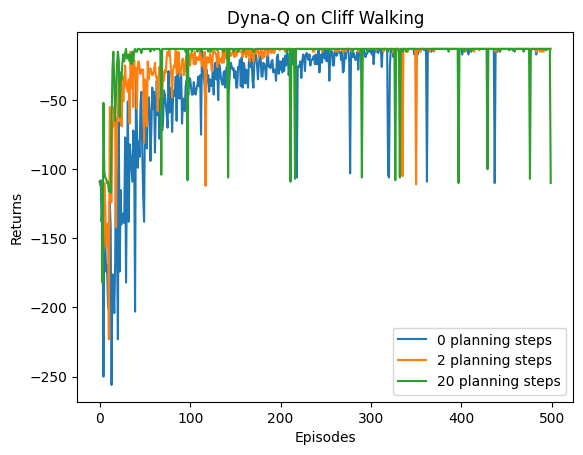

In [5]:
np.random.seed(0)
random.seed(0)
n_planning_list = [0, 2, 20]
for n_planning in n_planning_list:
    print('Q-planning步数为：%d' % n_planning)
    time.sleep(0.5)
    return_list = DynaQ_CliffWalking(n_planning)
    episodes_list = list(range(len(return_list)))
    plt.plot(episodes_list, return_list, label=str(n_planning) + ' planning steps')
plt.legend()
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Dyna-Q on Cliff Walking')
plt.show()